In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Hide warning messages

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Load the CSV

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Credit-Card-Fraud-Detection/data/creditcard.csv')

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist()) # To see column names

Dataset Shape:
(284807, 31)

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


Check data types

In [6]:
df.info() # To see column types, missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
df.describe() # Statistical summary (mean, std, min, max)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Check missing values

In [8]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [9]:
print(df.columns) # Check what variables/fields are available

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


Visualize the class distribution

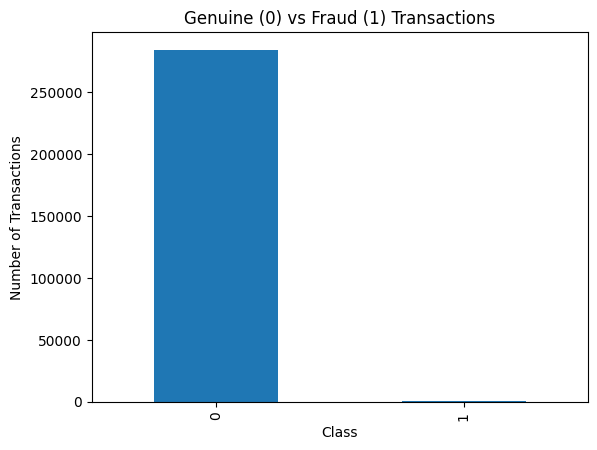

In [10]:
df['Class'].value_counts().plot(kind='bar') # Create a bar chart comparing the number of Genuine vs Fraud transactions

plt.title('Genuine (0) vs Fraud (1) Transactions')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.show()

Check duplicates

In [11]:
duplicate_count = df.duplicated().sum() # Check duplicate rows

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1081


In [12]:
print(df['Class'].value_counts()) # Count how many transactions are Genuine (0) and how many are Fraud (1)

print("\nPercentage distribution:")
print(df['Class'].value_counts(normalize=True) * 100) # Show the same count, but as a percentage of total transactions (helps see how imbalanced the data is)

Class
0    284315
1       492
Name: count, dtype: int64

Percentage distribution:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [13]:
print("Time statistics:")
display(df['Time'].describe())

print("\nAmount statistics:")
display(df['Amount'].describe())

Time statistics:


,Time
count,284807.000000
mean,94813.859575
std,47488.145955
min,0.000000
25%,54201.500000
50%,84692.000000
75%,139320.500000
max,172792.000000



Amount statistics:


,Amount
count,284807.000000
mean,88.349619
std,250.120109
min,0.000000
25%,5.600000
50%,22.000000
75%,77.165000
max,25691.160000


In [14]:
print("Number of zero Amount transactions:", (df['Amount'] == 0).sum())
print("Number of zero Time transactions:", (df['Time'] == 0).sum())

Number of zero Amount transactions: 1825
Number of zero Time transactions: 2


In [15]:
duplicate_rows = df[df.duplicated(keep=False)]

print("Duplicate rows:", len(duplicate_rows))

display(duplicate_rows.head())

Duplicate rows: 1854


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0


In [16]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1081


Remove duplicate rows

In [17]:
df_clean = df.drop_duplicates().copy() # Remove duplicate rows

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)
print("Duplicates remaining:", df_clean.duplicated().sum())

Original dataset shape: (284807, 31)
Cleaned dataset shape: (283726, 31)
Duplicates remaining: 0


In [18]:
print(df_clean['Class'].value_counts())

print("\nPercentage:")
print(df_clean['Class'].value_counts(normalize=True) * 100)

Class
0    283253
1       473
Name: count, dtype: int64

Percentage:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


In [19]:
print("Legitimate transactions:", (df_clean['Class'] == 0).sum())
print("Fraud transactions:", (df_clean['Class'] == 1).sum())

Legitimate transactions: 283253
Fraud transactions: 473


In [20]:
print("Total missing values:", df_clean.isnull().sum().sum())

Total missing values: 0


In [21]:
print("Unique Class values:", df_clean['Class'].unique())

Unique Class values: [0 1]


In [22]:
print(df_clean['Class'].value_counts())

Class
0    283253
1       473
Name: count, dtype: int64


In [23]:
df_clean.to_csv('/content/drive/MyDrive/Credit-Card-Fraud-Detection/data/creditcard_cleaned.csv', index=False)

print("Cleaned dataset saved successfully!")


Cleaned dataset saved successfully!


After cleaning dataset

In [24]:
print(df_clean.shape)
print(df_clean['Class'].value_counts())
print(df_clean.isnull().sum().sum())
print(df_clean['Class'].unique())

(283726, 31)
Class
0    283253
1       473
Name: count, dtype: int64
0
[0 1]


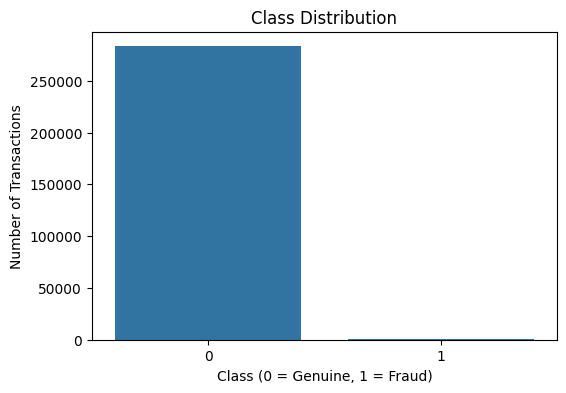

In [25]:
# EDA (Exploratory Data Analysis).
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(data=df_clean, x='Class')

plt.title('Class Distribution')
plt.xlabel('Class (0 = Genuine, 1 = Fraud)')
plt.ylabel('Number of Transactions')

plt.show()

In [26]:
class_counts = df_clean['Class'].value_counts()
class_percentages = df_clean['Class'].value_counts(normalize=True) * 100

print("Class Counts:")
print(class_counts)

print("\nClass Percentages:")
print(class_percentages)

Class Counts:
Class
0    283253
1       473
Name: count, dtype: int64

Class Percentages:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


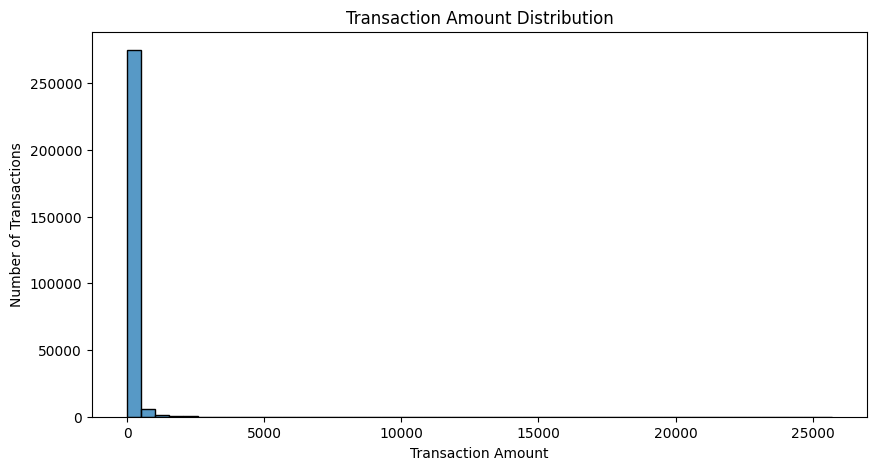

In [27]:
# Check the distribution of the Amount column
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_clean,
    x='Amount',
    bins=50
)

plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Number of Transactions')

plt.show()

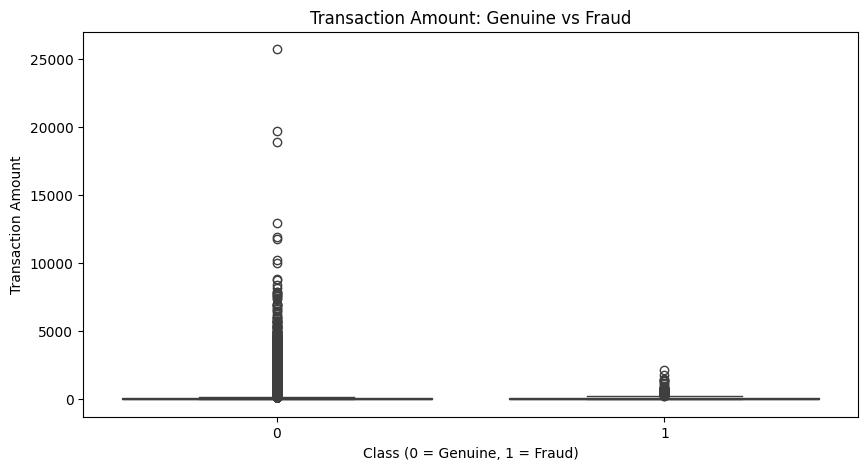

In [28]:
# Compare how the Amount varies between Fraudulent and Genuine transactions
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df_clean,
    x='Class',
    y='Amount'
)

plt.title('Transaction Amount: Genuine vs Fraud')
plt.xlabel('Class (0 = Genuine, 1 = Fraud)')
plt.ylabel('Transaction Amount')

plt.show()

In [29]:
amount_stats = df_clean.groupby('Class')['Amount'].describe()

print(amount_stats)

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      283253.0   88.413575  250.379023  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.871860  260.211041  0.0  1.00   9.82  105.89   2125.87


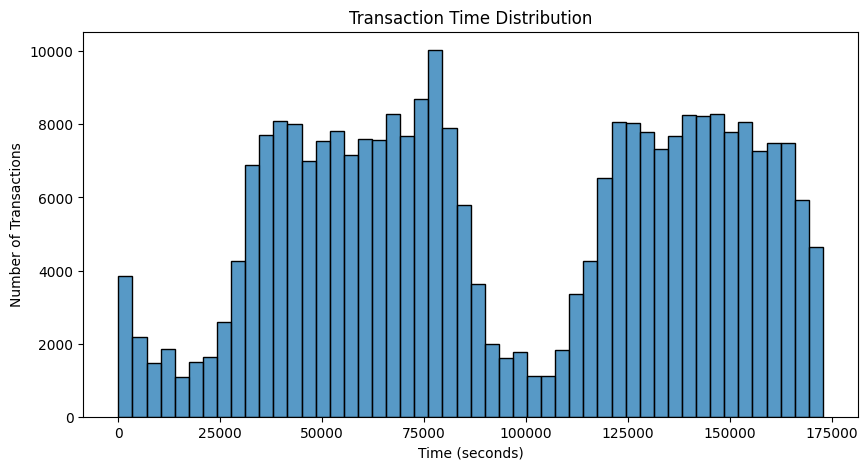

In [30]:
# Time Distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_clean,
    x='Time',
    bins=50
)

plt.title('Transaction Time Distribution')
plt.xlabel('Time (seconds)')
plt.ylabel('Number of Transactions')

plt.show()

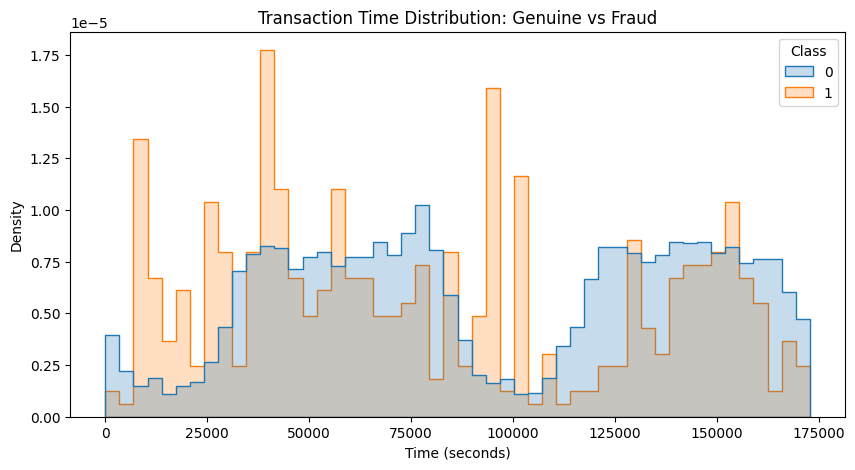

In [31]:
# Genuine vs Fraud Time
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_clean,
    x='Time',
    hue='Class',
    bins=50,
    element='step',
    stat='density',
    common_norm=False
)

plt.title('Transaction Time Distribution: Genuine vs Fraud')
plt.xlabel('Time (seconds)')
plt.ylabel('Density')

plt.show()

In [32]:
# Exact Time statistics
time_stats = df_clean.groupby('Class')['Time'].describe()

print(time_stats)

          count          mean           std    min      25%      50%  \
Class                                                                  
0      283253.0  94835.058093  47475.550607    0.0  54233.0  84711.0   
1         473.0  80450.513742  48636.179973  406.0  41203.0  73408.0   

            75%       max  
Class                      
0      139308.0  172792.0  
1      129095.0  170348.0  


In [33]:
# V1–V28 Feature Analysis
v_features = [f'V{i}' for i in range(1, 29)]

print("V1-V28 Summary Statistics:")
print(df_clean[v_features].describe().T)

V1-V28 Summary Statistics:
        count      mean       std         min       25%       50%       75%  \
V1   283726.0  0.005917  1.948026  -56.407510 -0.915951  0.020384  1.316068   
V2   283726.0 -0.004135  1.646703  -72.715728 -0.600321  0.063949  0.800283   
V3   283726.0  0.001613  1.508682  -48.325589 -0.889682  0.179963  1.026960   
V4   283726.0 -0.002966  1.414184   -5.683171 -0.850134 -0.022248  0.739647   
V5   283726.0  0.001828  1.377008 -113.743307 -0.689830 -0.053468  0.612218   
V6   283726.0 -0.001139  1.331931  -26.160506 -0.769031 -0.275168  0.396792   
V7   283726.0  0.001801  1.227664  -43.557242 -0.552509  0.040859  0.570474   
V8   283726.0 -0.000854  1.179054  -73.216718 -0.208828  0.021898  0.325704   
V9   283726.0 -0.001596  1.095492  -13.434066 -0.644221 -0.052596  0.595977   
V10  283726.0 -0.001441  1.076407  -24.588262 -0.535578 -0.093237  0.453619   
V11  283726.0  0.000202  1.018720   -4.797473 -0.761649 -0.032306  0.739579   
V12  283726.0 -0.000715  

In [34]:
# Genuine vs Fraud — feature mean comparison
feature_means = df_clean.groupby('Class')[v_features].mean().T

print(feature_means)

Class         0         1
V1     0.013439 -4.498280
V2    -0.009829  3.405965
V3     0.012853 -6.729599
V4    -0.010440  4.472591
V5     0.006769 -2.957197
V6     0.001251 -1.432518
V7     0.010447 -5.175912
V8    -0.002448  0.953255
V9     0.002613 -2.522124
V10    0.007663 -5.453274
V11   -0.006004  3.716347
V12    0.009476 -6.103254
V13    0.000762 -0.094324
V14    0.011668 -6.835946
V15    0.001166 -0.072830
V16    0.007845 -4.000956
V17    0.010963 -6.463285
V18    0.005120 -2.157071
V19   -0.001382  0.669143
V20   -0.000489  0.405043
V21   -0.001150  0.466550
V22   -0.000160  0.086639
V23    0.000360 -0.096464
V24    0.000393 -0.106643
V25   -0.000301  0.040615
V26    0.000065  0.050456
V27    0.001409  0.213774
V28    0.000418  0.078270


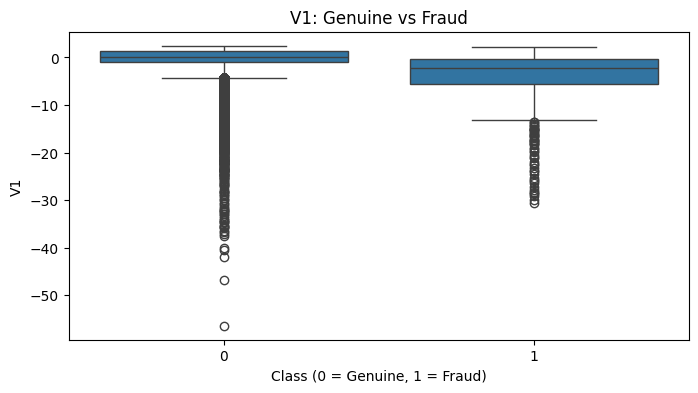

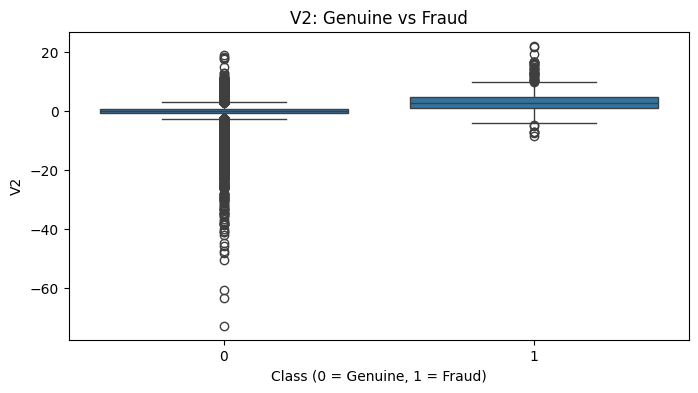

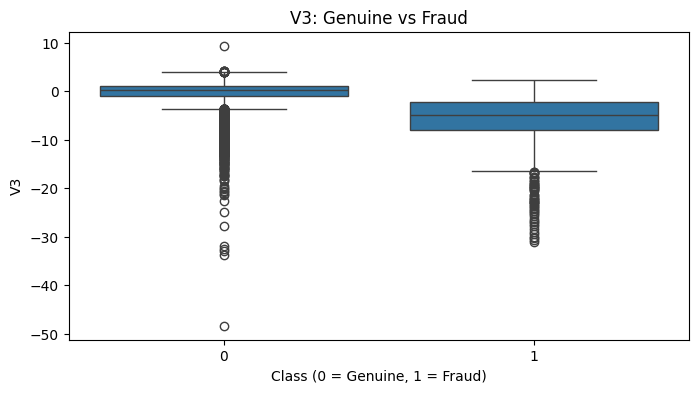

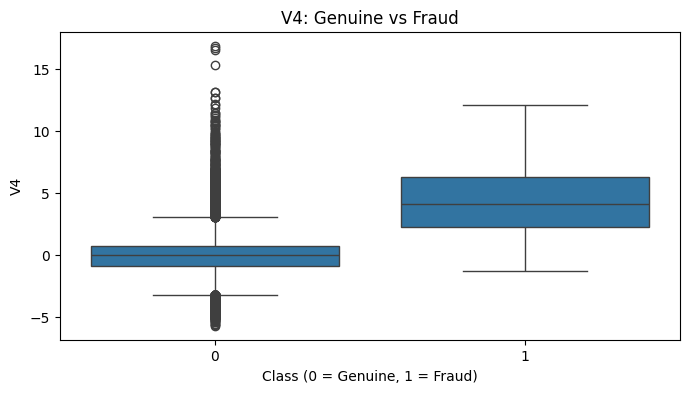

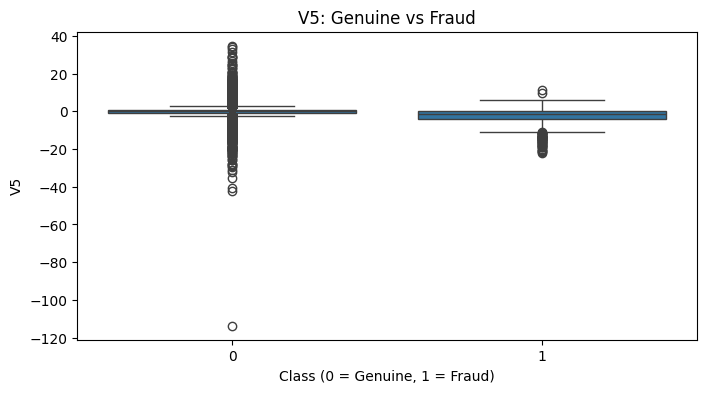

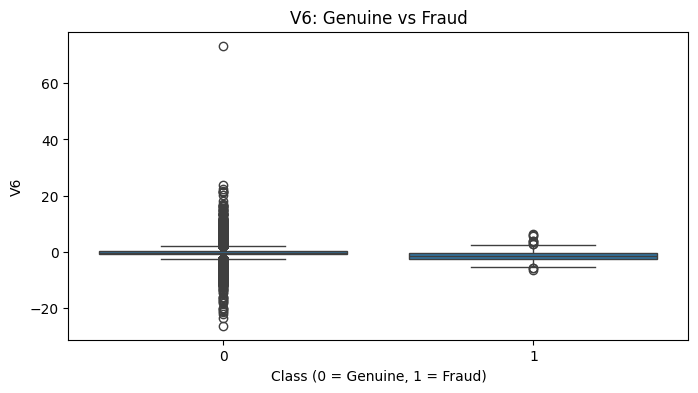

In [35]:
# Visual comparison
selected_features = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6']

for feature in selected_features:
    plt.figure(figsize=(8, 4))

    sns.boxplot(
        data=df_clean,
        x='Class',
        y=feature
    )

    plt.title(f'{feature}: Genuine vs Fraud')
    plt.xlabel('Class (0 = Genuine, 1 = Fraud)')
    plt.ylabel(feature)

    plt.show()

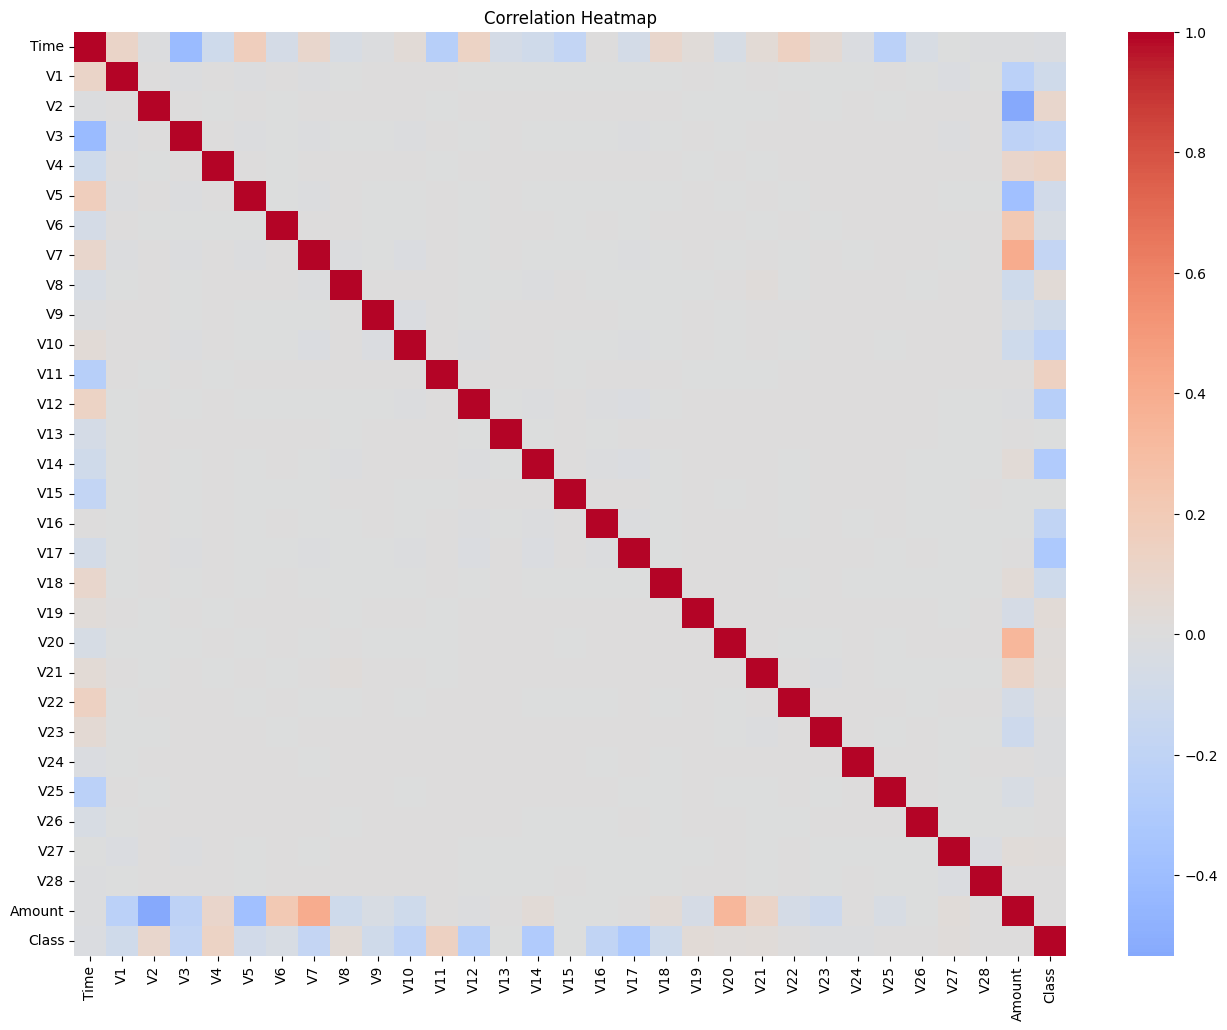

In [36]:
# Correlation Heatmap
plt.figure(figsize=(16, 12))

correlation_matrix = df_clean.corr()

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')
plt.show()

In [37]:
class_correlation = (
    df_clean.corr()['Class']
    .drop('Class')
    .sort_values(key=abs, ascending=False)
)

print("Correlation with Class:")
print(class_correlation)

Correlation with Class:
V17      -0.313498
V14      -0.293375
V12      -0.250711
V10      -0.206971
V16      -0.187186
V3       -0.182322
V7       -0.172347
V11       0.149067
V4        0.129326
V18      -0.105340
V1       -0.094486
V9       -0.094021
V5       -0.087812
V2        0.084624
V6       -0.043915
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
Time     -0.012359
V28       0.009682
V24      -0.007210
V23      -0.006333
Amount    0.005777
V22       0.004887
V26       0.004265
V13      -0.003897
V15      -0.003300
V25       0.003202
Name: Class, dtype: float64


In [38]:
# op correlated features visualize
top_features = class_correlation.head(5).index.tolist()

print("Top 5 features correlated with Class:")
print(top_features)

Top 5 features correlated with Class:
['V17', 'V14', 'V12', 'V10', 'V16']


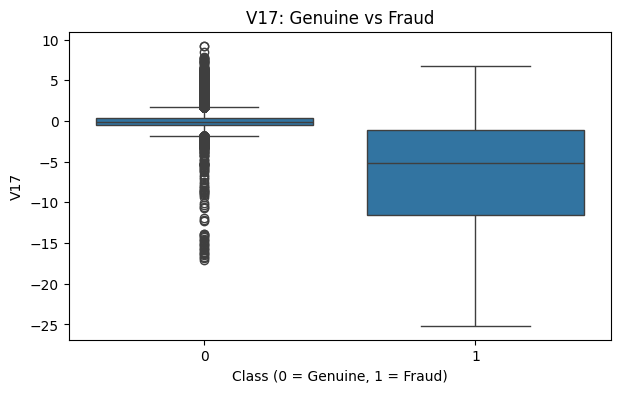

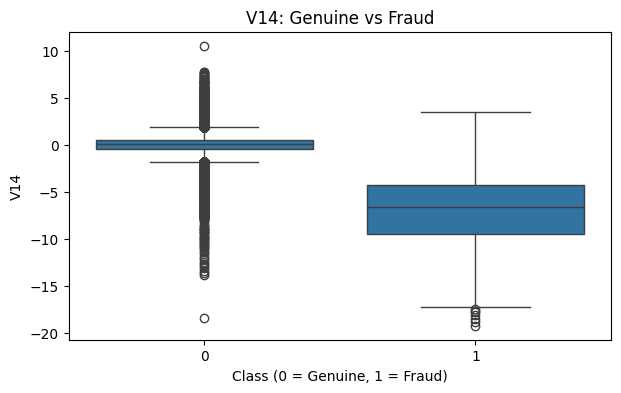

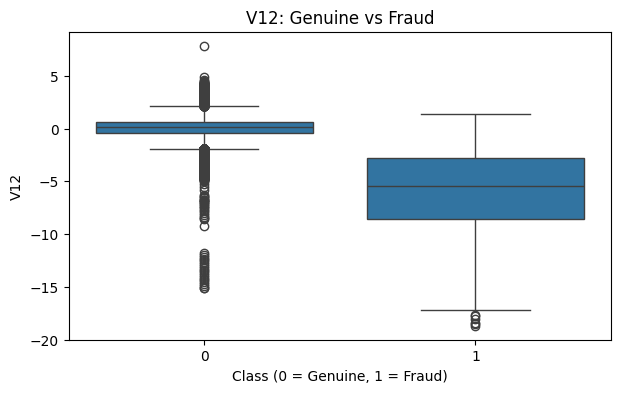

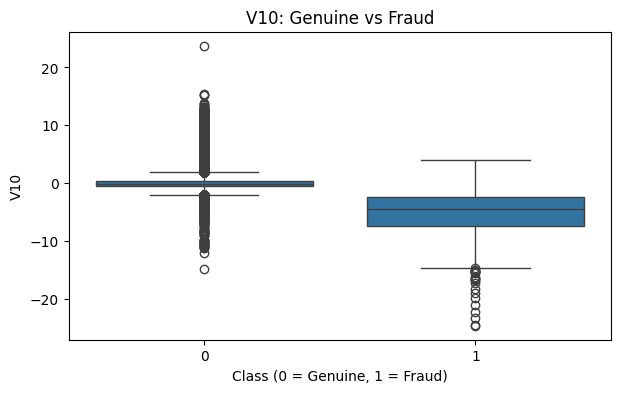

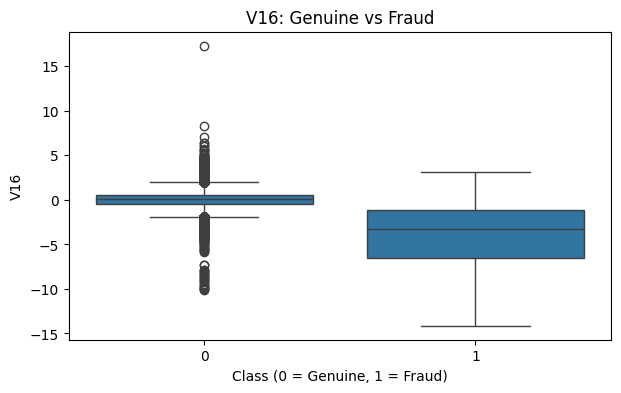

In [39]:
for feature in top_features:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df_clean,
        x='Class',
        y=feature
    )

    plt.title(f'{feature}: Genuine vs Fraud')
    plt.xlabel('Class (0 = Genuine, 1 = Fraud)')
    plt.ylabel(feature)

    plt.show()

In [40]:
# Genuine vs Fraud Comparison
class_summary = df_clean['Class'].value_counts().rename_axis('Class').reset_index(name='Count')

class_summary['Percentage'] = (
    class_summary['Count'] / len(df_clean) * 100
)

class_summary['Class'] = class_summary['Class'].map({
    0: 'Genuine',
    1: 'Fraud'
})

print(class_summary)

     Class   Count  Percentage
0  Genuine  283253    99.83329
1    Fraud     473     0.16671


In [41]:
amount_comparison = df_clean.groupby('Class')['Amount'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

amount_comparison.index = ['Genuine', 'Fraud']

print(amount_comparison)

          count        mean  median         std  min       max
Genuine  283253   88.413575   22.00  250.379023  0.0  25691.16
Fraud       473  123.871860    9.82  260.211041  0.0   2125.87


In [42]:
time_comparison = df_clean.groupby('Class')['Time'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

time_comparison.index = ['Genuine', 'Fraud']

print(time_comparison)

          count          mean   median           std    min       max
Genuine  283253  94835.058093  84711.0  47475.550607    0.0  172792.0
Fraud       473  80450.513742  73408.0  48636.179973  406.0  170348.0


In [43]:
summary = pd.DataFrame({
    'Genuine': [
        (df_clean['Class'] == 0).sum(),
        df_clean.loc[df_clean['Class'] == 0, 'Amount'].mean(),
        df_clean.loc[df_clean['Class'] == 0, 'Amount'].median()
    ],
    'Fraud': [
        (df_clean['Class'] == 1).sum(),
        df_clean.loc[df_clean['Class'] == 1, 'Amount'].mean(),
        df_clean.loc[df_clean['Class'] == 1, 'Amount'].median()
    ]
}, index=[
    'Transaction Count',
    'Average Amount',
    'Median Amount'
])

print(summary)

                         Genuine      Fraud
Transaction Count  283253.000000  473.00000
Average Amount         88.413575  123.87186
Median Amount          22.000000    9.82000


### EDA Observations

- The dataset contains 283,253 normal transactions and 473 fraudulent transactions.
- Fraudulent transactions represent a very small portion of the dataset, indicating severe class imbalance.
- The average transaction amount is higher for fraudulent transactions (123.87) than for normal transactions (88.41).
- However, the median transaction amount for fraudulent transactions (9.82) is lower than that of normal transactions (22.00).
- This difference between mean and median indicates that transaction amounts are highly skewed and some high-value transactions influence the average.

In [44]:
# Train/Test Split
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_clean.drop('Class', axis=1)
y = df_clean['Class']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training set shape: (226980, 30)
Testing set shape: (56746, 30)

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Testing class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [45]:
# Scaling
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Features to scale
scale_features = ['Time', 'Amount']

# Fit scaler only on training data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_features] = scaler.fit_transform(
    X_train[scale_features]
)

# Use the same fitted scaler for test data
X_test_scaled[scale_features] = scaler.transform(
    X_test[scale_features]
)

print("Training data after scaling:")
print(X_train_scaled[scale_features].describe())

print("\nTesting data after scaling:")
print(X_test_scaled[scale_features].describe())

Training data after scaling:
               Time        Amount
count  2.269800e+05  2.269800e+05
mean  -1.518880e-16  7.309531e-17
std    1.000002e+00  1.000002e+00
min   -1.998400e+00 -3.596386e-01
25%   -8.561822e-01 -3.364866e-01
50%   -2.123526e-01 -2.697972e-01
75%    9.363191e-01 -4.287453e-02
max    1.640237e+00  7.962087e+01

Testing data after scaling:
               Time        Amount
count  56746.000000  56746.000000
mean      -0.009386      0.001741
std        0.999221      1.091001
min       -1.998358     -0.359639
25%       -0.860031     -0.337300
50%       -0.219639     -0.271811
75%        0.929386     -0.048378
max        1.640111    104.175192


In [46]:
scaler.fit_transform(X_train)

array([[ 1.04549909,  1.14719836, -1.04203246, ...,  0.09278213,
        -0.15619266, -0.22943372],
       [-0.29869002, -0.67791131,  0.99194846, ..., -0.04986389,
         0.15383143, -0.33119698],
       [ 0.67839667,  0.97765362,  0.0162054 , ...,  0.11132947,
        -0.16581986, -0.29880852],
       ...,
       [ 1.19385202, -0.45214212,  0.70655379, ..., -0.62638332,
         0.28835592, -0.20908921],
       [-0.95824459,  0.63781446,  0.21468286, ...,  0.10812079,
         0.09533138, -0.3392941 ],
       [-0.89610272,  0.52361687, -0.13216317, ...,  0.1416972 ,
        -0.0070969 , -0.30955042]])

In [47]:
scaler.transform(X_test)

array([[-0.70776084,  0.62846035, -0.03507436, ...,  0.00334824,
         0.00256256, -0.31284623],
       [ 1.27387205, -0.10690835,  0.71666883, ...,  0.96769184,
         0.79940005, -0.35174494],
       [-1.34811061, -0.86164079,  0.85283366, ...,  0.01560762,
         0.34674777,  0.01177083],
       ...,
       [-0.44196799,  0.60372332, -0.11740337, ...,  0.02988069,
         0.07761042, -0.32244884],
       [ 0.68907303,  1.05584343,  0.08623043, ..., -0.16707329,
        -0.13668677, -0.35601729],
       [-1.76535189,  0.63786439,  0.04036693, ..., -0.21956371,
         0.02075116, -0.29473961]])

In [48]:
print("Original Time mean:", X_train['Time'].mean())
print("Scaled Time mean:", X_train_scaled['Time'].mean())

print("\nOriginal Amount mean:", X_train['Amount'].mean())
print("Scaled Amount mean:", X_train_scaled['Amount'].mean())

Original Time mean: 94900.22438981409
Scaled Time mean: -1.5188797928927686e-16

Original Amount mean: 88.38712432813462
Scaled Amount mean: 7.30953074279599e-17


In [49]:
print(X_train_scaled.head())

            Time        V1        V2        V3        V4        V5        V6  \
226238  1.045499  2.238954 -1.724499 -2.151484 -2.577803  0.993668  3.565492   
134253 -0.298690 -1.315062  1.630783  0.597001 -0.038359 -0.404580 -0.965712   
186465  0.678397  1.908801  0.021184 -2.087997  0.129310  1.161468  0.605244   
149493 -0.074929  1.811257  0.316556  0.316751  3.880231  0.048454  1.020163   
18461  -1.376728  1.358817 -1.120881  0.550266 -1.547659 -1.194950  0.275448   

              V7        V8        V9  ...       V20       V21       V22  \
226238 -1.785957  0.860122 -1.264003  ... -0.323810 -0.149574 -0.049333   
134253  0.212249  0.735381 -1.267926  ... -0.067580 -0.238898 -0.946773   
186465 -0.022371  0.180296  0.283819  ... -0.210474  0.293609  1.095842   
149493 -0.734868  0.233651  0.681423  ... -0.228032  0.138869  0.700422   
18461  -1.201843  0.212889 -2.094285  ... -0.361686 -0.340972 -0.636442   

             V23       V24       V25       V26       V27       V28  

In [50]:
# Calculate Class Weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculate class weights using training data only
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

print("Classes:", classes)
print("Class weights:", class_weight_dict)

Classes: [0 1]
Class weights: {np.int64(0): np.float64(0.5008340614822464), np.int64(1): np.float64(300.23809523809524)}


Validation Split

In [51]:
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.1875,   # 0.1875 × 80% ≈ 15% of total dataset
    random_state=42,
    stratify=y_train
)

print("Final Train shape:", X_train_final.shape)
print("Validation shape :", X_val.shape)
print("Test shape       :", X_test_scaled.shape)

Final Train shape: (184421, 30)
Validation shape : (42559, 30)
Test shape       : (56746, 30)


In [52]:
# Convert data to NumPy arrays

X_train_final_np = X_train_final.values
X_val_np = X_val.values
X_test_np = X_test_scaled.values

y_train_final_np = y_train_final.values
y_val_np = y_val.values
y_test_np = y_test.values

X_train_seq = X_train_final_np.reshape(X_train_final_np.shape[0], X_train_final_np.shape[1], 1)
X_val_seq   = X_val_np.reshape(X_val_np.shape[0], X_val_np.shape[1], 1)
X_test_seq  = X_test_np.reshape(X_test_np.shape[0], X_test_np.shape[1], 1)

print("Train shape:", X_train_final_np.shape)
print("Val shape  :", X_val_np.shape)
print("Test shape :", X_test_np.shape)

Train shape: (184421, 30)
Val shape  : (42559, 30)
Test shape : (56746, 30)


Reshape + Save

In [53]:
import os
BASE_PATH = '/content/drive/MyDrive/Credit-Card-Fraud-Detection/processed_data/'
os.makedirs(BASE_PATH, exist_ok=True)

# For MLP (2D) — CSV
pd.DataFrame(X_train_final_np).to_csv(BASE_PATH + 'X_train.csv', index=False)
pd.DataFrame(X_val_np).to_csv(BASE_PATH + 'X_val.csv', index=False)
pd.DataFrame(X_test_np).to_csv(BASE_PATH + 'X_test.csv', index=False)
pd.DataFrame(y_train_final_np).to_csv(BASE_PATH + 'y_train.csv', index=False)
pd.DataFrame(y_val_np).to_csv(BASE_PATH + 'y_val.csv', index=False)
pd.DataFrame(y_test_np).to_csv(BASE_PATH + 'y_test.csv', index=False)

# For CNN/LSTM/GRU (3D) — NumPy format
np.save(BASE_PATH + 'X_train_seq.npy', X_train_seq)
np.save(BASE_PATH + 'X_val_seq.npy', X_val_seq)
np.save(BASE_PATH + 'X_test_seq.npy', X_test_seq)

print("All files have been successfully saved!")

print("Location:", BASE_PATH)

All files have been successfully saved!
Location: /content/drive/MyDrive/Credit-Card-Fraud-Detection/processed_data/
